# Taobots — Simulation Analysis

Loads the three log files written by a run and visualises population health, per-bot survival, resource dynamics, and focal-individual behaviour.

**Log files expected in `../logs/` (relative to this notebook):**
- `default_<timestamp>.csv` — population-level stats every 60 ticks
- `default_deaths.csv` — one row per death
- `default_focal.csv` — N=5 focal bots sampled every 10 ticks

Run a simulation first: `make sim` or `make headless`

In [ ]:
import glob
import pathlib

import matplotlib.pyplot as plt
import pandas as pd

LOGS = pathlib.Path('../logs')
WORLD = 'default'

plt.rcParams.update({
    'figure.facecolor': '#0a1a1a',
    'axes.facecolor':   '#0d2020',
    'axes.edgecolor':   '#304040',
    'axes.labelcolor':  '#b0c0b0',
    'xtick.color':      '#607060',
    'ytick.color':      '#607060',
    'text.color':       '#b0c0b0',
    'grid.color':       '#1e3030',
    'grid.linewidth':   0.5,
    'legend.facecolor': '#0d2020',
    'legend.edgecolor': '#304040',
})

ARCHETYPE_COLORS = {
    'wanderer':   '#00dc78',
    'specialist': '#ff500a',
    'survivor':   '#dcdc00',
    'hoarder':    '#c0c0c0',
    'default':    '#6090a0',
}

ELEMENT_COLORS = {
    'WOOD':  '#3CA028',
    'WATER': '#1E50DC',
    'METAL': '#C0C0C0',
    'FIRE':  '#FF500A',
    'EARTH': '#D2B41E',
}

# Load files
pop_files = sorted(glob.glob(str(LOGS / f'{WORLD}_2*.csv')))
pop = pd.read_csv(pop_files[-1]) if pop_files else None
deaths = pd.read_csv(LOGS / f'{WORLD}_deaths.csv')
focal  = pd.read_csv(LOGS / f'{WORLD}_focal.csv')

print(f'Population log: {pop_files[-1] if pop_files else "not found"} ({len(pop)} rows)')
print(f'Deaths: {len(deaths)} records')
print(f'Focal:  {len(focal)} records, {focal["entity_id"].nunique()} unique bots')

## 1. Population organ integrity over time

In [ ]:
if pop is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # Organ integrity — mean across population for the four active organs
    ax = axes[0]
    organ_cols = {
        'mean_organ_wood':  ('Wood',  ELEMENT_COLORS['WOOD'],  2.0),
        'mean_organ_fire':  ('Fire',  ELEMENT_COLORS['FIRE'],  1.2),
        'mean_organ_water': ('Water', ELEMENT_COLORS['WATER'], 1.2),
        'mean_organ_earth': ('Earth', ELEMENT_COLORS['EARTH'], 1.2),
    }
    for col, (label, color, lw) in organ_cols.items():
        if col in pop.columns:
            ax.plot(pop['tick'], pop[col], color=color, linewidth=lw, label=label)
    ax.axhline(25, color='#ff500a', linewidth=0.7, linestyle='--', label='flee threshold (Wood=25)')
    ax.axhline(20, color='#888800', linewidth=0.7, linestyle=':', label='Fire lockout (20)')
    ax.set_ylabel('Organ value (0–100)')
    ax.set_ylim(0, 105)
    ax.legend(loc='upper right', ncol=3)
    ax.set_title('Mean Organ Integrity — Population')
    ax.grid(True)

    ax2 = axes[1]
    ax2.stackplot(
        pop['tick'],
        pop['resources_wood'], pop['resources_water'], pop['resources_metal'],
        pop['resources_fire'], pop['resources_earth'],
        labels=['Wood', 'Water', 'Metal', 'Fire', 'Earth'],
        colors=[ELEMENT_COLORS[e] for e in ['WOOD', 'WATER', 'METAL', 'FIRE', 'EARTH']],
        alpha=0.8,
    )
    ax2.set_ylabel('Live resource count')
    ax2.set_xlabel('Tick')
    ax2.legend(loc='upper right', ncol=5)
    ax2.set_title('Resource Availability')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print('No population log found — run headless mode to generate one')

## 2. Deaths — survival by archetype

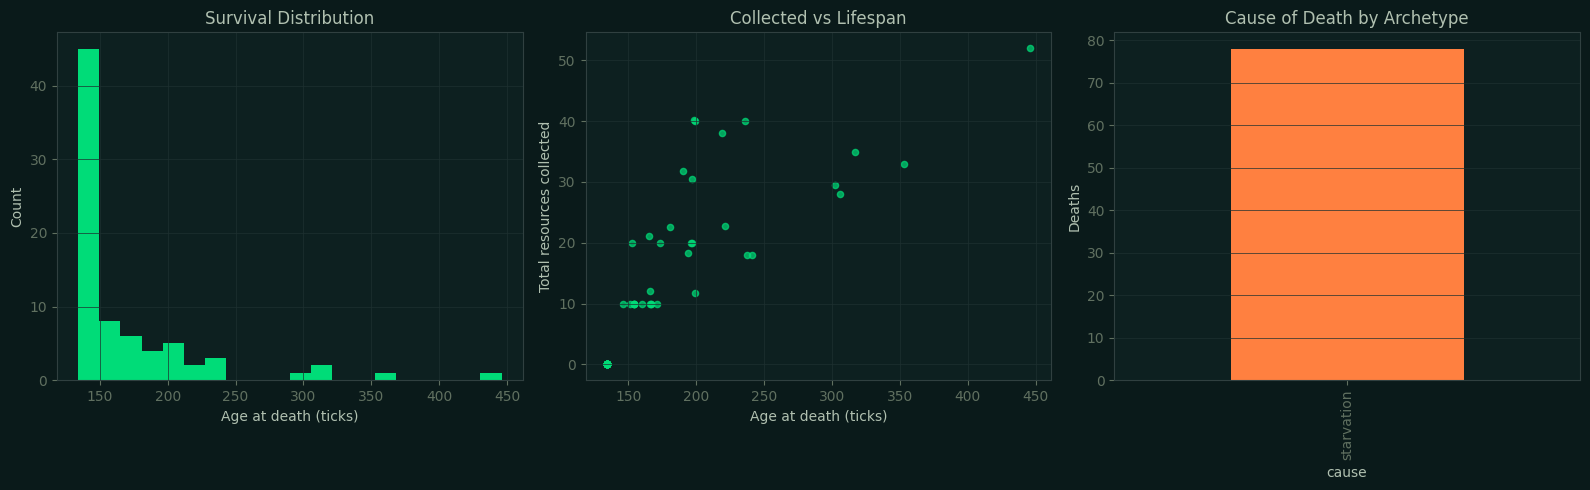

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age at death by archetype
ax = axes[0]
archetypes = deaths['archetype'].unique() if 'archetype' in deaths.columns else ['default']
arch_col = 'archetype' if 'archetype' in deaths.columns else None

if arch_col:
    for arch in sorted(archetypes):
        subset = deaths[deaths['archetype'] == arch]['age_ticks']
        ax.hist(subset, bins=20, alpha=0.7, color=ARCHETYPE_COLORS.get(arch, '#888'),
                label=arch, edgecolor='none')
    ax.legend()
else:
    ax.hist(deaths['age_ticks'], bins=20, color='#00dc78', edgecolor='none')

ax.set_xlabel('Age at death (ticks)')
ax.set_ylabel('Count')
ax.set_title('Survival Distribution')
ax.grid(True)

# Total resources collected at death
ax = axes[1]
elem_cols = [c for c in deaths.columns if c.startswith('collected_')]
deaths['total_collected'] = deaths[elem_cols].sum(axis=1)

if arch_col:
    for arch in sorted(archetypes):
        subset = deaths[deaths['archetype'] == arch]
        ax.scatter(subset['age_ticks'], subset['total_collected'],
                   color=ARCHETYPE_COLORS.get(arch, '#888'), label=arch, alpha=0.7, s=20)
    ax.legend()
else:
    ax.scatter(deaths['age_ticks'], deaths['total_collected'], color='#00dc78', alpha=0.7, s=20)

ax.set_xlabel('Age at death (ticks)')
ax.set_ylabel('Total resources collected')
ax.set_title('Collected vs Lifespan')
ax.grid(True)

# Cause of death: starvation vs hazard damage
ax = axes[2]
deaths['cause'] = deaths['damage_taken_total'].apply(
    lambda d: 'hazard' if d > 0 else 'starvation'
)
cause_counts = deaths.groupby(['archetype', 'cause']).size().unstack(fill_value=0) if arch_col \
    else deaths['cause'].value_counts()

if arch_col and isinstance(cause_counts, pd.DataFrame):
    x = range(len(cause_counts))
    if 'starvation' in cause_counts.columns:
        ax.bar(x, cause_counts['starvation'], color='#ff8040', label='starvation', alpha=0.85)
    if 'hazard' in cause_counts.columns:
        bottom = cause_counts.get('starvation', pd.Series([0]*len(cause_counts))).values
        ax.bar(
            x, cause_counts['hazard'], bottom=bottom,
            color='#dc3030', label='hazard', alpha=0.85,
        )
    ax.set_xticks(list(x))
    ax.set_xticklabels(cause_counts.index, rotation=15)
    ax.legend()
else:
    cause_counts.plot(kind='bar', ax=ax, color=['#ff8040','#dc3030'], edgecolor='none')

ax.set_ylabel('Deaths')
ax.set_title('Cause of Death by Archetype')
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

# Summary table
if arch_col:
    summary = deaths.groupby('archetype').agg(
        n_deaths=('age_ticks','count'),
        mean_age=('age_ticks','mean'),
        median_age=('age_ticks','median'),
        max_age=('age_ticks','max'),
        mean_collected=('total_collected','mean'),
        pct_starvation=('cause', lambda x: (x=='starvation').mean()*100),
    ).round(1)
    display(summary)

## 3. Focal individuals — organ integrity and storage

In [ ]:
focal_ids = focal['entity_id'].unique()
n = len(focal_ids)

ORGAN_COLS = ['WOOD', 'FIRE', 'WATER', 'EARTH', 'METAL']

fig, axes = plt.subplots(n, 2, figsize=(16, 4 * n), squeeze=False)

for row_i, eid in enumerate(sorted(focal_ids)):
    bot = focal[focal['entity_id'] == eid].sort_values('tick')
    arch = bot['archetype'].iloc[0] if 'archetype' in bot.columns else 'unknown'

    # Organ traces
    ax = axes[row_i, 0]
    for elem in ORGAN_COLS:
        col = f'organ_{elem}'
        if col in bot.columns:
            lw = 2.0 if elem == 'WOOD' else 1.0
            ax.plot(bot['tick'], bot[col], color=ELEMENT_COLORS[elem],
                    linewidth=lw, label=elem)
    ax.axhline(25, color='#ff500a', linewidth=0.6, linestyle='--', label='flee (Wood=25)')
    ax.axhline(20, color='#888800', linewidth=0.6, linestyle=':', label='lockout (Fire=20)')
    ax.set_ylim(0, 105)
    ax.set_ylabel('Organ value')
    ax.set_title(f'Bot #{eid}  ({arch})  — Organs')
    ax.legend(loc='upper right', ncol=3, fontsize=8)
    ax.grid(True)

    # Storage levels
    ax2 = axes[row_i, 1]
    for elem, ecol in ELEMENT_COLORS.items():
        col = f'storage_{elem}'
        if col in bot.columns:
            ax2.plot(bot['tick'], bot[col], color=ecol, linewidth=1.2, label=elem)
    ax2.set_ylabel('Storage level')
    ax2.set_title(f'Bot #{eid}  ({arch})  — Storage')
    ax2.legend(loc='upper right', ncol=5, fontsize=8)
    ax2.grid(True)

plt.tight_layout()
plt.show()

## 4. Focal individuals — collection activity (interval deltas)

In [4]:
interval_cols = [c for c in focal.columns if c.startswith('interval_') and c != 'interval_damage']
elem_names = [c.replace('interval_','') for c in interval_cols]

fig, axes = plt.subplots(len(focal_ids), 1, figsize=(14, 4 * len(focal_ids)), squeeze=False)

for row_i, eid in enumerate(sorted(focal_ids)):
    bot = focal[focal['entity_id'] == eid].sort_values('tick')
    arch = bot['archetype'].iloc[0] if 'archetype' in bot.columns else 'unknown'
    ax = axes[row_i, 0]

    bottoms = pd.Series([0.0] * len(bot))
    for icol, ename in zip(interval_cols, elem_names):
        vals = bot[icol].values
        ax.bar(bot['tick'], vals, bottom=bottoms.values,
               color=ELEMENT_COLORS.get(ename, '#888'), label=ename,
               width=9, alpha=0.85)
        bottoms += vals

    ax2 = ax.twinx()
    ax2.plot(bot['tick'], bot['interval_damage'], color='#dc3030',
             linewidth=1.2, linestyle='--', label='damage taken')
    ax2.set_ylabel('Damage taken', color='#dc3030')
    ax2.tick_params(axis='y', labelcolor='#dc3030')

    ax.set_title(f'Bot #{eid}  ({arch})  — Collection per interval')
    ax.set_ylabel('Resources collected')
    ax.set_xlabel('Tick')
    ax.legend(loc='upper left', ncol=5, fontsize=8)
    ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

NameError: name 'focal_ids' is not defined

## 5. Behaviour state breakdown

In [ ]:
state_colors = {
    'searching':  '#6090a0',
    'seeking':    '#00dc78',
    'collecting': '#00ff40',
    'fleeing':    '#dcdc00',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# State distribution pie per archetype
ax = axes[0]
state_dist = focal.groupby('behavior_state').size()
wedge_colors = [state_colors.get(s, '#888') for s in state_dist.index]
ax.pie(state_dist, labels=state_dist.index, colors=wedge_colors,
       autopct='%1.0f%%', startangle=90)
ax.set_title('Overall Behaviour State Distribution')

# State over time (stacked area for all focal bots)
ax2 = axes[1]
state_by_tick = focal.groupby(['tick','behavior_state']).size().unstack(fill_value=0)
states = ['searching','seeking','collecting','fleeing']
present = [s for s in states if s in state_by_tick.columns]
ax2.stackplot(
    state_by_tick.index,
    [state_by_tick[s] for s in present],
    labels=present,
    colors=[state_colors[s] for s in present],
    alpha=0.8,
)
ax2.set_xlabel('Tick')
ax2.set_ylabel('Focal bot count')
ax2.set_title('Behaviour States Over Time (focal bots)')
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.show()

## 6. Metabolism balance check

Checks whether bots are collecting enough of each element to sustain their organs.
Storage drain rates per 10-tick interval (base, without Earth cascade penalty):
```
FIRE  0.015 × 10 = 0.15    WATER 0.012 × 10 = 0.12 (max; scales with speed)
EARTH 0.010 × 10 = 0.10    WOOD  0.004 × 10 = 0.04 (structural maintenance)
METAL 0.002 × 10 = 0.02    (armor upkeep; least acute)
```
An interval where collected < demand means that element's organ was degrading.
Earth below threshold doubles all drain rates — deficit compounds across all organs.

In [ ]:
# Base storage drain per 10-tick interval (FOCAL_INTERVAL = 10)
ORGAN_DEMAND_PER_INTERVAL = {
    'FIRE':  0.15,
    'WATER': 0.12,  # upper bound — scales down with Water organ / speed
    'EARTH': 0.10,
    'WOOD':  0.04,  # structural maintenance
    'METAL': 0.02,  # armor upkeep
}

fig, ax = plt.subplots(figsize=(14, 5))

for eid in sorted(focal_ids):
    bot = focal[focal['entity_id'] == eid].sort_values('tick')
    arch = bot['archetype'].iloc[0] if 'archetype' in bot.columns else 'default'
    color = ARCHETYPE_COLORS.get(arch, '#888')

    net = pd.Series([0.0] * len(bot), index=bot.index)
    for elem, demand in ORGAN_DEMAND_PER_INTERVAL.items():
        icol = f'interval_{elem}'
        if icol in bot.columns:
            net += bot[icol].values - demand

    ax.plot(bot['tick'], net.values, color=color, alpha=0.8, label=f'#{eid} ({arch})')

ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
ylim = ax.get_ylim()
if ylim[0] < 0:
    ax.fill_between(ax.get_xlim(), ylim[0], 0, color='#500000', alpha=0.2, label='deficit zone')
ax.set_xlabel('Tick')
ax.set_ylabel('Net resource balance per interval (all elements)')
ax.set_title('Metabolic Balance — positive = surplus collection, negative = organ degrading')
ax.legend(loc='upper right')
ax.grid(True)
plt.tight_layout()
plt.show()

## 7. Diagnostic summary

In [ ]:
print('=== DEATH SUMMARY ===')
print(f'Total deaths recorded: {len(deaths)}')
print(f'Mean age at death:      {deaths["age_ticks"].mean():.1f} ticks')
print(f'Median age at death:    {deaths["age_ticks"].median():.1f} ticks')

no_collect = (deaths['total_collected'] == 0).sum()
pct = 100 * no_collect / len(deaths)
print(f'Died with 0 resources collected: {no_collect} / {len(deaths)} ({pct:.0f}%)')
print()

if 'archetype' in deaths.columns:
    print('=== SURVIVAL BY ARCHETYPE ===')
    cols = ['count', 'mean', '50%', 'max']
    print(deaths.groupby('archetype')['age_ticks'].describe()[cols].round(1).to_string())
    print()

print('=== METABOLIC BALANCE (focal bots, all intervals) ===')
for elem, demand in ORGAN_DEMAND_PER_INTERVAL.items():
    icol = f'interval_{elem}'
    if icol in focal.columns:
        avg = focal[icol].mean()
        pct_deficit = (focal[icol] < demand).mean() * 100
        print(
            f'  {elem:<6} demand={demand:.3f}  mean_collected={avg:.3f}  '
            f'intervals_in_deficit={pct_deficit:.0f}%'
        )

print()
if pop is not None:
    print('=== ORGAN INTEGRITY (population mean, final tick) ===')
    last = pop.iloc[-1]
    for col in ['mean_organ_wood', 'mean_organ_fire', 'mean_organ_water', 'mean_organ_earth']:
        if col in last:
            print(f'  {col.replace("mean_organ_", ""):<6}: {last[col]:.1f}')
    print()
    print('=== RESOURCE ECONOMY ===')
    min_alive = pop['n_resources_alive'].min()
    initial = pop['n_resources_alive'].iloc[0]
    print(f'Min live resources during run: {min_alive} / {initial} initial')
    print(f'Resources crashed to zero: {"YES" if min_alive == 0 else "no"}')